In [1]:
import yaml
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from OptimusPrimus import OptimusPrimus

from mineral_utils import Paleodetector, slice_spectrum

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
mineral_name =  "Apatite"  # Must match a key in MINERAL_LIBRARY

sample_mass_kg =  0.000001       # Sample mass in kg (e.g., 0.01 for 10g)

x_bins = np.linspace(0, 100000, 300)        #Track length bins in nm
x_mids = x_bins[:-1] + np.diff(x_bins) / 2

age = 5600.

In [3]:
CONFIG = yaml.safe_load(open('Data/basic_config.yaml', 'r'))
MINERAL_LIBRARY = yaml.safe_load(open('Data/mineral_library.yaml', 'r'))

In [4]:
# --- Setup & Verification ---
mineral_config = MINERAL_LIBRARY.get(mineral_name)
if not mineral_config:
    raise ValueError(f"Mineral '{mineral_name}' not found in MINERAL_LIBRARY.")

mineral = Paleodetector(mineral_config)

Initialized Paleodetector: Apatite


In [5]:
total_fission_tracks = np.array(mineral.integrate_fission_spectrum(x_bins, age, sample_mass_kg))

Calculating spontaneous fission background...


In [6]:
sliced_large = slice_spectrum(x_bins, total_fission_tracks, bulk_etching_depth=1000, pit_width=5000.)

In [7]:
IMAGE_SPEC = "ARCI URAS26I3"
MODEL_SPEC = "obsidian_a066b033beta20" 

In [8]:
evaluator = OptimusPrimus(IMAGE_SPEC, MODEL_SPEC)

Configuration Loaded:
  Image Folder: Data/images/ARCI URAS26I3/tiles
  Model Path: Data/segmentation_models/obsidian_a066b033beta20.pth
  Output Directory: Data/inference_results/ARCI URAS26I3_obsidian_a066b033beta20.csv
  Using Device: cpu


In [9]:
evaluator.inference_from_file()
measured, _ = np.histogram(evaluator.ellipses['len_um']*1000, bins=x_bins)

In [10]:
evaluator.efficiency_distribution_from_file()
read = evaluator.apply_detection_model_efficiency(x_bins, sliced_large, meas_error=2000.)

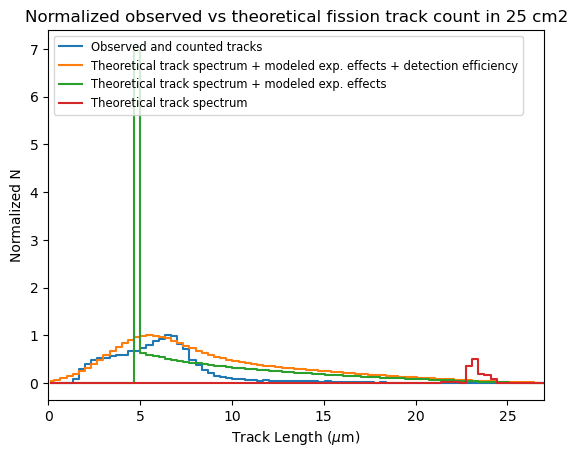

In [11]:
plt.step(x_mids/1000., measured/measured.max(), where='mid', label='Observed and counted tracks')
plt.step(x_mids/1000., read/read.max(), where='mid', label='Theoretical track spectrum + modeled exp. effects + detection efficiency')
plt.step(x_mids/1000., sliced_large/read.max(), where='mid', label='Theoretical track spectrum + modeled exp. effects')
plt.step(x_mids/1000., total_fission_tracks/read.max(), where='mid', label='Theoretical track spectrum')
plt.xlim(0, 27)
plt.legend(fontsize='small', loc='upper left')
plt.xlabel(r"Track Length ($\mu$m)")
plt.ylabel(r"Normalized N")
plt.title(f"Normalized observed vs theoretical fission track count in 25 cm2")
plt.show()